# Manufacturing Operating Conditions Analysis
## Capstone Project
Research Question:
Can machine learning be used to predict whether manuacturing operating conditions are optimal or non-optimal based on machine and process-related variables?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Data

In [2]:
df = pd.read_csv("Equipment dataset.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.shape

(10000, 14)

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## Data Cleaning

In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(10000, 14)

In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# EDA (Exploratory Data Analysis)

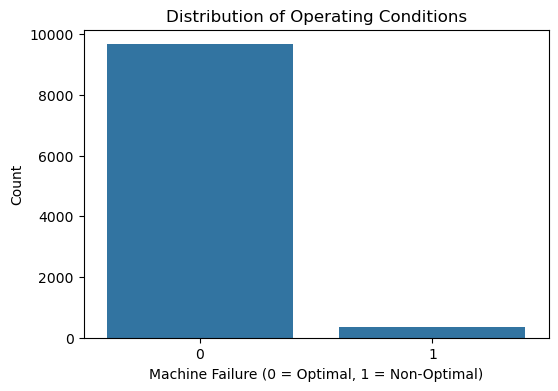

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Machine failure',
    data=df
)

plt.title('Distribution of Operating Conditions')
plt.xlabel('Machine Failure (0 = Optimal, 1 = Non-Optimal)')
plt.ylabel('Count')

plt.show()

In [12]:
df_model = df.drop(
    columns=[
        'UDI',
        'Product ID',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ]
)

In [13]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [14]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [15]:
df_model.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [16]:
df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [17]:
df_model['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

# The target variable identifies whether operating conditions were optimal (0) or non-optimal (1). Before building the models, the distribution of each class was examined to determine whether one outcome occurred significantly more often than the other.

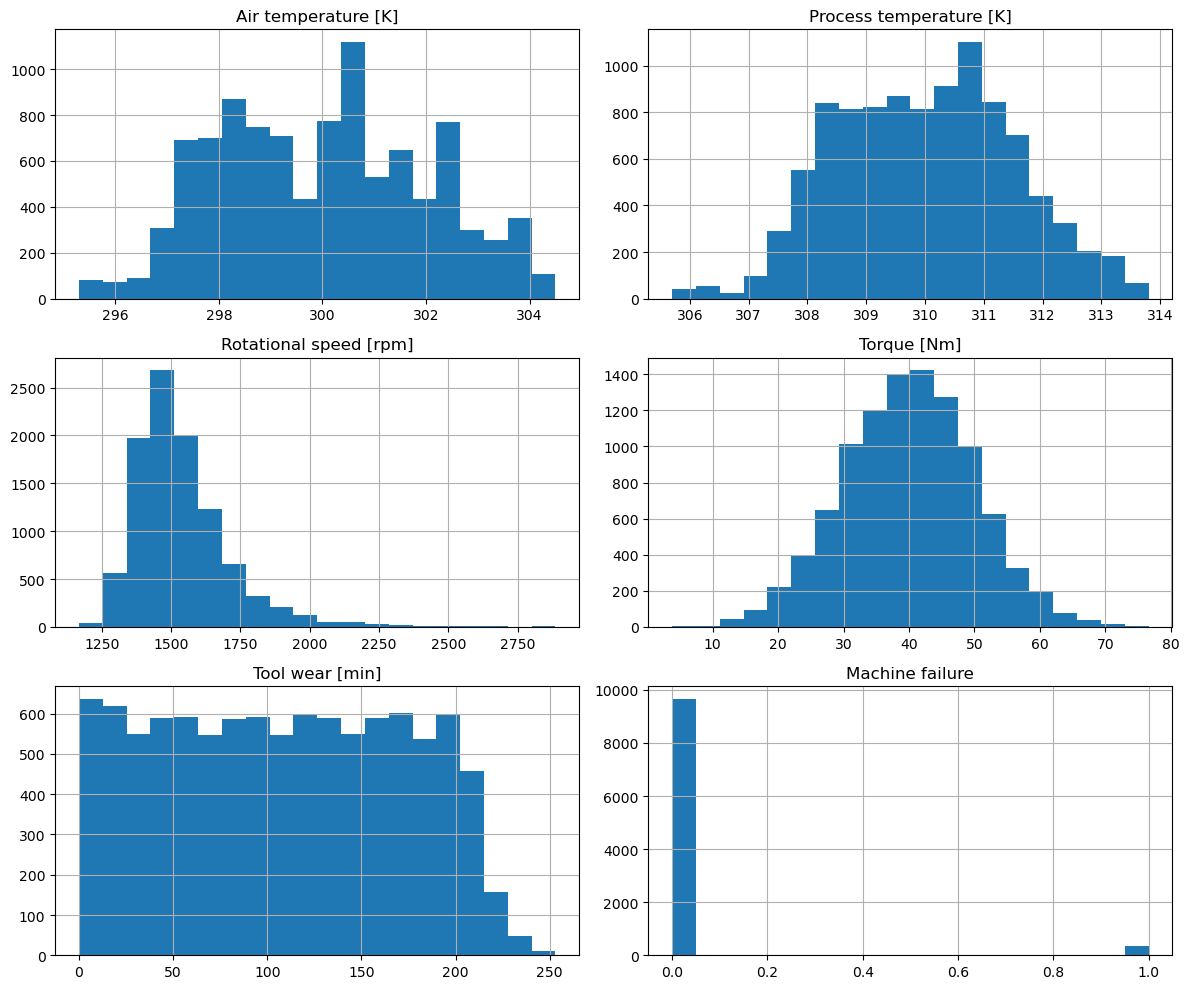

In [18]:
df_model.hist(
    figsize=(12,10),
    bins=20
)

plt.tight_layout()
plt.show()

# Outlier Analysis

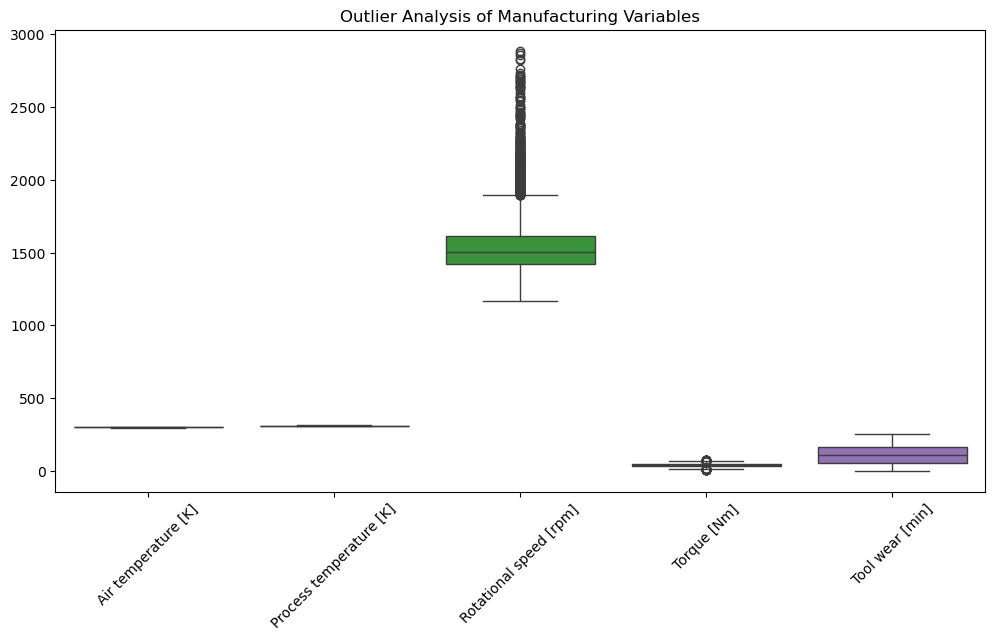

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_model[
        [
            'Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]'
        ]
    ]
)

plt.xticks(rotation=45)
plt.title('Outlier Analysis of Manufacturing Variables')

plt.show()

## Relationship Between Temperature Variables

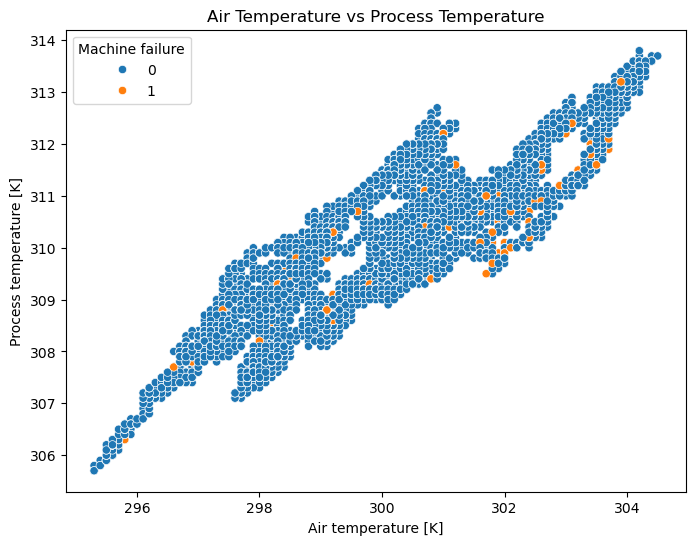

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_model,
    x='Air temperature [K]',
    y='Process temperature [K]',
    hue='Machine failure'
)

plt.title('Air Temperature vs Process Temperature')

plt.show()

## Baseline Logistic Regression Model

In [21]:
X = df_model.drop(
    columns=['Machine failure']
)

y = df_model['Machine failure']

In [22]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


# Baseline Logistic Regression Model

Logistic Regression was used as a starting point to evaluate how effectively operating conditions could be classified using the available machine and process data.

In [23]:
X = df_model.drop(
    columns=['Machine failure']
)

y = df_model['Machine failure']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
X_train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4058,M,302.0,310.9,1456,47.2,54
1221,M,297.0,308.3,1399,46.4,132
6895,M,301.0,311.6,1357,45.6,137
9863,L,298.9,309.8,1411,56.3,84
8711,L,297.1,308.5,1733,28.7,50


In [29]:
df_model = pd.get_dummies(
    df_model,
    columns=['Type'],
    drop_first=True
)

df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [30]:
df_model.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')

In [32]:
X = df_model.drop(columns=['Machine failure'])
y = df_model['Machine failure']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred = lr.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9675


In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1928    4]
 [  61    7]]


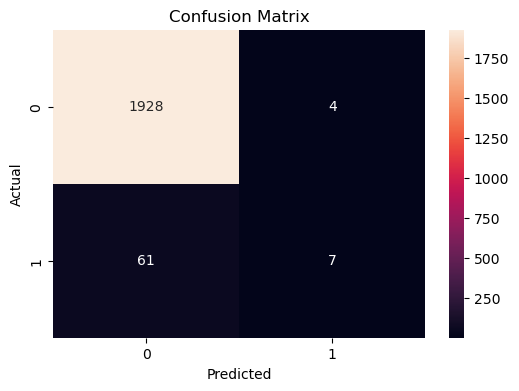

In [41]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Baseline Model Results

The Logistic Regression model achieved an accuracy of 96.75% on the test dataset.

While the overall accuracy was high, the classification report and confusion matrix revealed that the model struggled to identify non-optimal operating conditions. The model correctly identified only a small portion of failure observations, resulting in a low recall score for the minority class.

This suggests that the dataset is imbalanced and that accuracy alone is not sufficient for evaluating model performance. Additional models and evaluation techniques will be explored in future work.

# KNN Model

In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

In [44]:
knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

In [45]:
knn_pred = knn.predict(
    X_test_scaled
)

In [46]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.974


In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        knn_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



In [48]:
from sklearn.metrics import confusion_matrix

knn_cm = confusion_matrix(
    y_test,
    knn_pred
)

print(knn_cm)

[[1928    4]
 [  48   20]]


# Comparing the 2 Models
Two classification models were evaluated: Logistic Regression and KNN.

The Logistic Regression model achieved an accuracy of 96.75%, while the KNN model achieved an accuracy of 97.40%.

Although both models achieved high overall accuracy, KNN demonstrated a stronger performance in identifying non-optimal operating conditions. The KNN model achieved a recall of 29% for the failure class compared to 10% for Logistic Regression.

Since the objective of this project is to identify non-optimal operating conditions, recall for the failure is important. Missing a potential failure may result in downtime, maintenance costs, and reduced equipment performance.

Based on the evaluation metrics, KNN appears to be the stronger model for this dataset and will be considered for further investigation.

# Conclusion

The objective of this analysis was to investigate whether machine learning can be used to predict optimal and non-optimal manufacturing operating conditions using equipment and process-related variables.

Data cleaning confirmed that the dataset contained no missing values or duplicate records. Feature engineering was performed by converting the machine type variable into numerical features suitable for machine learning models.

Exploratory data analysis was conducted using histograms, boxplots, and scatterplots. The analysis presented a strong relationship between air temperature and process temperature, while variables such as rotational speed, torque, and tool wear showed greater variability and potential outliers. These observations were retained because they may represent legitimate manufacturing operating conditions.

Two classification models were evaluated: Logistic Regression and KNN (K-Nearest Neighbors). Logistic Regression achieved an accuracy of 96.75%, while KNN achieved an accuracy of 97.40%. Although both models performed well overall, KNN demonstrated stronger performance in identifying non-optimal operating conditions, achieving higher recall and F1-score for the failure class.

These results suggest that machine learning can be used to identify non-optimal operating conditions based on machine and process-related variables. Future work will focus on refining model performance, investigating additional classification techniques, and developing recommendations that can support manufacturing reliability and operational decision-making.